# Анализ доходимости на мероприятия: итоги и рекомендации

**Клиент:** образовательный проект (школьная профориентация)  
**Формат:** серия из 5 очных мероприятий на единую тему: «Почему важно на любом этапе школы думать об образовании. Практические советы родителям и ученикам»  
**Задача:** оценить, какие факторы влияют на долю зарегистрировавшихся, реально дошедших до мероприятия (доходимость), и дать рекомендации по ее повышению для будущих кампаний.

## Как считали доходимость

Доходимость = визиты / регистрации × 100%.

Из анализа исключены:
- регистрации с датой визита раньше даты регистрации — данные с нарушением логической последовательности, признак ошибки выгрузки;
- регистрации, поданные более чем за 35 дней до мероприятия — по условиям кампании продвижение и регистрация стартовали ровно за месяц до события, поэтому более ранние даты не могут отражать реальное поведение пользователей и, скорее всего, являются артефактом данных (~10% исходного датасета).

Осознанно жертвуем частью объема данных ради чистоты выборки: включение подозрительных записей исказило бы оценки доходимости сильнее, чем их отсутствие.

## Структура анализа

1. Доходимость в разрезе источника трафика, типа трафика, дня и часа 
   регистрации, класса участника и времени до мероприятия
2. Статистическая проверка значимости найденных различий 
   (хи-квадрат тест независимости + попарные сравнения с поправкой 
   на множественное тестирование)
3. Сравнение мероприятий друг с другом и поиск закономерностей 
   в динамике
4. Итоговые рекомендации по перераспределению рекламного бюджета 
   и таргетингу

### Начало работы

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

In [2]:
SAVE_ALL_PICTS = False # если надо сохранить все картинки
PATH_TO_FILE = "Кейс_Анализ Мероприятия Тех.xlsx"

In [3]:
registrations = pd.read_excel(PATH_TO_FILE, sheet_name='registrations')
visits = pd.read_excel(PATH_TO_FILE, sheet_name='visits')
events = pd.read_excel(PATH_TO_FILE, sheet_name='events')
print("Регистрации: ", registrations.shape)
print("Визиты: ", visits.shape)
print("Мероприятия: ", events.shape)

Регистрации:  (101930, 7)
Визиты:  (58807, 2)
Мероприятия:  (5, 2)


### Подготовка данных к работе

In [4]:
registrations["utm_source"] = registrations["utm_source"].fillna("organic")
registrations["utm_medium"] = registrations["utm_medium"].fillna("organic")
visits = visits.drop_duplicates(subset='RegistrationID') # удаляем дубликаты
print(f'Было 58807 записей - стало {visits.shape[0]} записи\nУдалено: {58_807-visits.shape[0]} записей или {(1-visits.shape[0]/58_807)*100:.0f}%')

Было 58807 записей - стало 36814 записи
Удалено: 21993 записей или 37%


In [5]:
# Тут просто соединяем таблицы
new_reg = registrations.merge(visits, on='RegistrationID', how='left')
# Сократим длинное название, для вывода на графиках (иначе портит графики):
new_reg.loc[new_reg['utm_source'].str.contains('Mailigen', na=False), 'utm_source'] = 'Mailigen'
new_reg = new_reg.merge(events, left_on='EventID', right_on='ExhibitionID', how='left')

# Вычисляем сколько дней от регистрации до мероприятия
new_reg['DaysDiff'] = (new_reg['EventDate'] - pd.to_datetime(new_reg['Created'].dt.date)).dt.days

#new_reg = new_reg[(new_reg['DaysDiff'] > 0)]
new_reg = new_reg[(new_reg['DaysDiff'] > 0) & (new_reg['DaysDiff'] <= 35)] # 35 дней это ровно 5 недель
print(new_reg.shape)
new_reg.head()

(89450, 11)


,RegistrationID,EventID,Who,Class,Created,utm_source,utm_medium,VisitID,ExhibitionID,EventDate,DaysDiff
36,79069,3,Ученик,11.0,2018-09-27 20:17:22,organic,organic,NaN,3,2018-10-01,4
37,100705,17,Ученик,9.0,2019-01-17 13:14:31,organic,organic,NaN,17,2019-02-03,17
54,100034666,17,Ученик,10.0,2019-01-26 11:59:57,organic,organic,42956.0,17,2019-02-03,8
270,89543,17,Родитель,9.0,2019-01-05 17:26:17,organic,organic,39197.0,17,2019-02-03,29
271,90876,17,Родитель,10.0,2019-01-08 12:25:03,organic,organic,39717.0,17,2019-02-03,26


Итоговый датасет сформирован с учётом следующих правил:  
— удалены дубли (сокращение на 37%);  
— исключены аномальные временные метки (регистрации после мероприятия и ранее чем за 5 недель);  
— записи без метки класса (>7% данных) сохранены в выборке для сохранения репрезентативности распределений, но не учитывались в разрезе по классам.

### 1. Исследование доходимости по основным разрезам

In [6]:
def get_attendance(by, df):
    """ 
        Функция возвращает количество регистраций/визитов и доходимость
            by - название столбца или их список, по которому/ым группируем данные
            df - датафрейм
        agg(Registrations_count = ('RegistrationID', 'count'), ...) - так можно было, без переименования столбцов 0_0
        """
    df = df.groupby(by, as_index = False).agg({'RegistrationID':'count', 'VisitID':'count'}) \
               .rename(columns={'RegistrationID':'Registrations_count', 'VisitID':'Visits_count'})
    df['Attendance'] = df['Visits_count'] / df['Registrations_count'] * 100
    return df

def draw_attendance_hist(by, df, xlabel = '', title = 'Посещаемость', save=False, rotate=False):
    """ 
        Функция выводит графики доходимости и активности
    """
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    axes[0].grid(axis='y', linestyle='-', alpha=0.3)
    bars1 = axes[0].bar(df[by], df['Attendance'], color='skyblue')
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel('Посещаемость (%)')
    axes[0].set_title('График доходимости')
    axes[0].set_ylim(0, 100)
    axes[0].set_axisbelow(True)

    for bar in bars1:
        height = bar.get_height()
        axes[0].annotate(f'{int(height)}%',  # Значение процента
                         xy=(bar.get_x() + bar.get_width() / 2, height),  # Координаты
                         xytext=(0, 3),  # Смещение текста
                         textcoords="offset points",
                         ha='center', va='bottom')
    
    axes[1].bar(df[by], df['Registrations_count'], color='skyblue')
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel('Количество регистраций')
    axes[1].set_title('График активности')
    axes[1].grid(axis='y', linestyle='-', alpha=0.3)
    axes[1].set_axisbelow(True)

    axes[0].spines[:].set_visible(False)
    axes[1].spines[:].set_visible(False)
    
    fig.suptitle(title)
    
    if rotate:
        axes[0].tick_params(axis='x', rotation=45)
        axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    if save:
        plt.savefig(title + '.svg', format='svg', dpi=100, bbox_inches='tight')
    plt.show()

**Доходимость по мероприятиям:**

,EventID,Registrations_count,Visits_count,Attendance
0,15,3705,823,22.213225
1,3,42728,16879,39.503370
2,17,27913,12326,44.158636
3,18,4139,1002,24.208746
4,20,10965,2905,26.493388


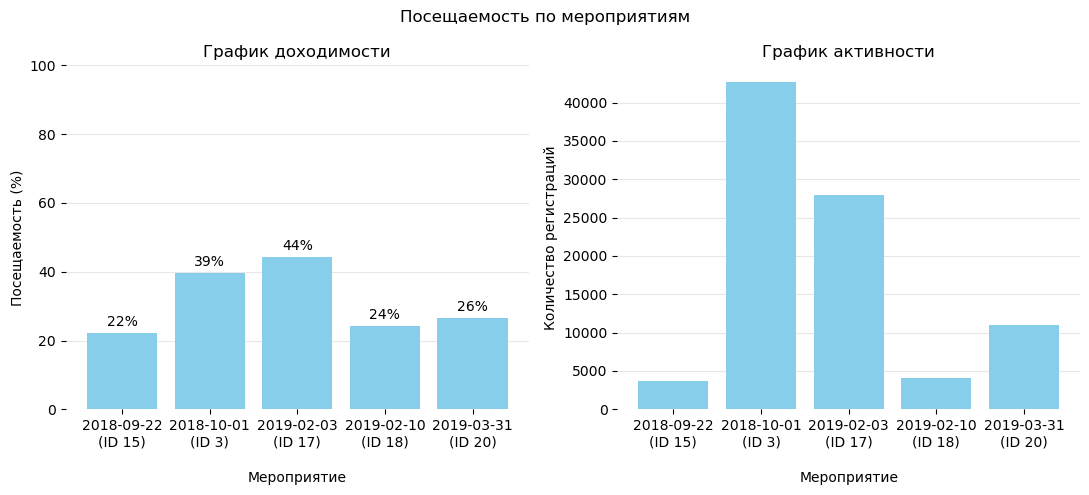

In [7]:
df = get_attendance(by='EventID', df=new_reg)
df = df.merge(events, left_on='EventID', right_on='ExhibitionID').sort_values('EventDate').reset_index(drop=True)
df['EventName'] = df['EventDate'].astype(str) + '\n(ID ' + df['EventID'].astype(str) + ')\n'
display(df.iloc[:, :4])

draw_attendance_hist(by='EventName', df=df, xlabel='Мероприятие', title='Посещаемость по мероприятиям', save=SAVE_ALL_PICTS)

- Диапазон показателей: Доходимость по мероприятиям варьируется от **22.1%** до **44.1%**, а объем регистраций — от **3.7 тыс. до 42 тыс.** человек.
- Лидер по доходимости: Мероприятие **2019-02-03 (ID 17)** показывает лучший результат конверсии (44.1%) при хорошей базе регистраций (~28 тыс.). Стоит изучить практики его организации.
- Масштаб и эффективность: Самое массовое событие **2018-10-01 (ID 3)** (>42 тыс. регистраций) удерживает высокий процент доходимости (**39.4%**), что говорит об эффективной работе с аудиторией.
- Зоны риска: Мероприятие **2018-09-22 (ID 15)** имеет самую низкую доходимость (**22.1%**) и минимум регистраций, что указывает на низкий интерес аудитории или ошибки в позиционировании.

**Доходимость ученик/родитель:**

,Who,Registrations_count,Visits_count,Attendance
0,Другое,154,34,22.077922
1,Родитель,30873,11156,36.135134
2,Ученик,58423,22745,38.931585


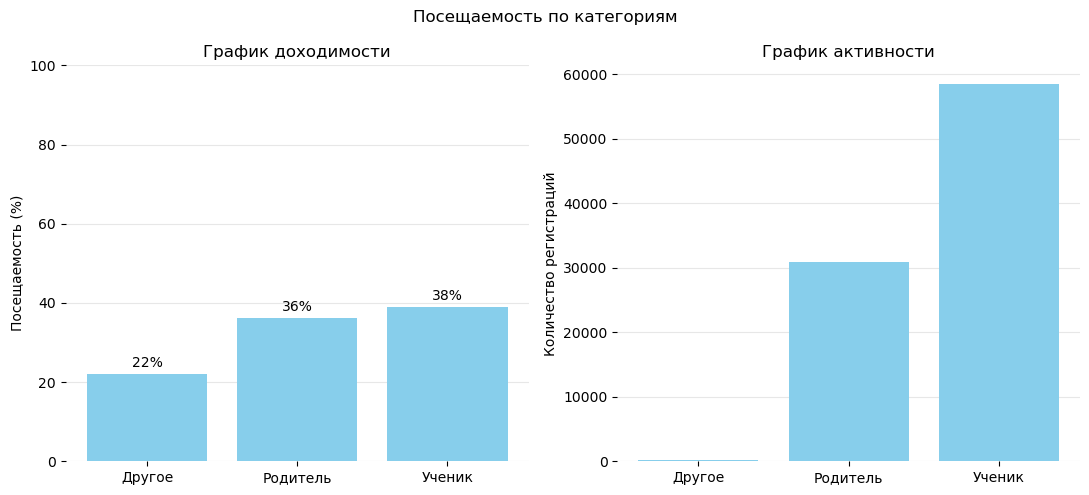

In [8]:
df = get_attendance(by='Who', df=new_reg)
display(df)
draw_attendance_hist(by='Who', df=df, xlabel='', title='Посещаемость по категориям', save=SAVE_ALL_PICTS)

- Лидер по доходимости: Категория **«Ученик»** доминирует по объему регистраций (~59 тыс.) и показывает самую высокую доходимость (~39%).
- Вторая по значимости аудитория: Категория **«Родитель»** охватывает около 31 тыс. регистраций с доходимостью порядка 36%, что близко к показателям учеников.
- Минимальная доля: Категория **«Другое»** имеет крайне малый объем регистраций (почти 0 на графике активности) и самую низкую доходимость (~22%).

**Доходимость по классам школы**

,Class,Registrations_count,Visits_count,Attendance
0,1,514,162,31.517510
1,2,146,24,16.438356
2,3,201,45,22.388060
3,4,314,53,16.878981
4,5,620,133,21.451613
5,6,2097,574,27.372437
6,7,3820,1083,28.350785
7,8,7958,2773,34.845439
8,9,16613,6372,38.355505
9,10,20904,8897,42.561232


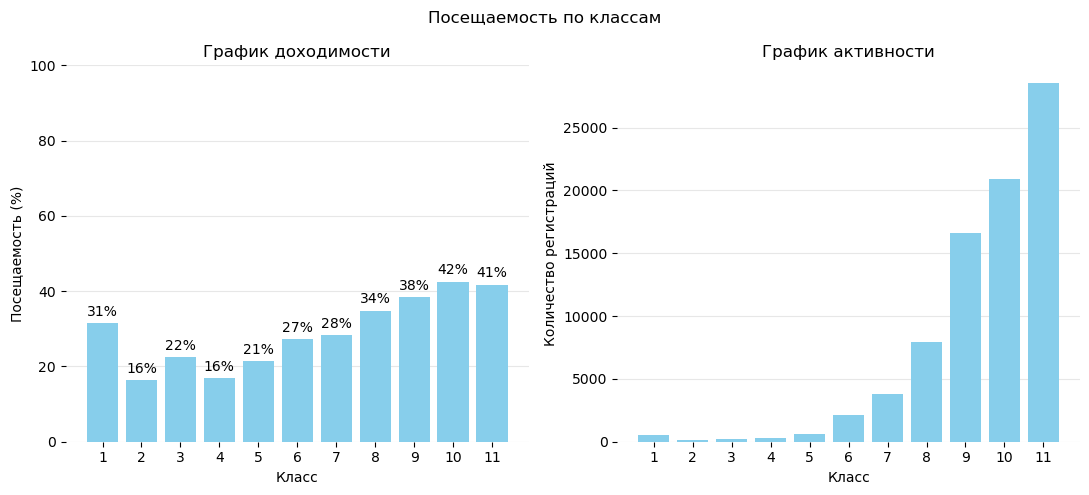

In [9]:
df = get_attendance(by='Class', df=new_reg)
df['Class'] = df['Class'].astype('int32').astype(str)

display(df)
draw_attendance_hist(by='Class', df=df, xlabel='Класс', title='Посещаемость по классам', save=SAVE_ALL_PICTS)

- Динамика активности: Наблюдается экспоненциальный рост количества регистраций от младших классов к старшим, с пиковыми значениями в **10 и 11 классах** (более 20–28 тыс. регистраций).
- Динамика доходимости: Процент доходимости также заметно выше в средней и старшей школе (особенно в **8–11 классах**, где показатель держится на уровне 35–42%).
- Младшие классы: Ученики 1–7 классов регистрируются реже и показывают более низкую доходимость (в среднем 15–30%), за исключением первоклассников, у которых отмечается локальный подъем конверсии (~32%).

**Доходимость utm_source**

,utm_source,Registrations_count,Visits_count,Attendance
43,yandex,2790,1443,51.720430
23,organic,30380,14975,49.292298
26,propostuplenie,10435,3896,37.335889
1,Mailigen,7372,2695,36.557244
37,vk,8139,2665,32.743580
10,fb,24022,6144,25.576555
14,import,1814,453,24.972437
7,Другое,4498,1664,36.994220


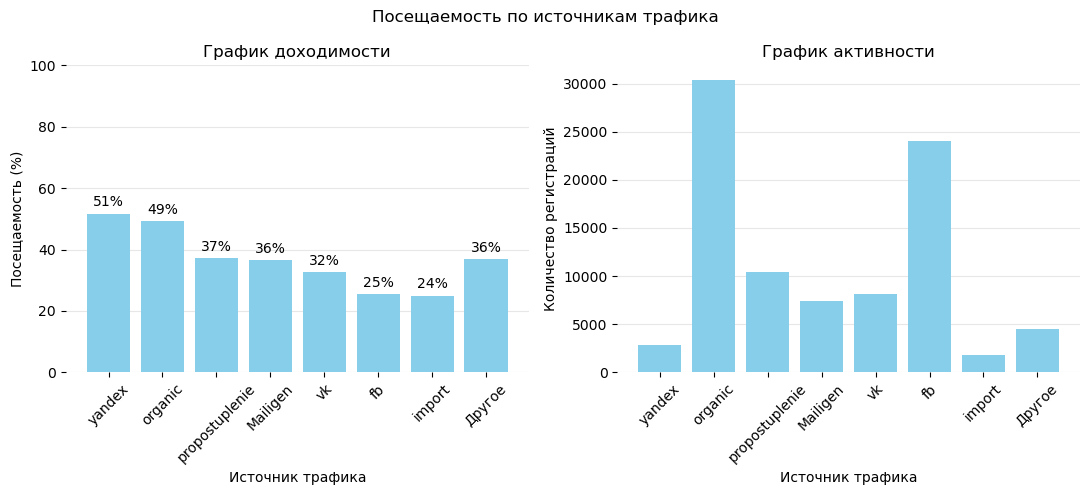

In [10]:
df = get_attendance(by='utm_source', df=new_reg)

# если кол-во регистраций меньше 2% от общего числа, то соотносим это в отдельную общую категорию - Другое
border = df['Registrations_count'].sum()*0.02

small_groups = df[df['Registrations_count'] < border].sum()
df = df[df['Registrations_count'] >= border].sort_values(by='Attendance', ascending=False)

df.loc[len(df)] = ['Другое', small_groups['Registrations_count'], small_groups['Visits_count'], 
                   small_groups['Visits_count'] / small_groups['Registrations_count'] * 100]

display(df)
draw_attendance_hist(by='utm_source', df=df, xlabel='Источник трафика', title='Посещаемость по источникам трафика', save=SAVE_ALL_PICTS, rotate=True)

- Лидер по доходимости: Наивысший процент конверсии в посещение показывают **yandex** (\~52%) и **organic** (\~50%), существенно превосходя остальные каналы.
- Лидер по активности: Основной объем регистраций генерируют каналы **organic** (более 30 тыс.) и **fb** (около 24 тыс.).
- Качество трафика: Несмотря на высокую популярность *fb*, его доходимость держится на низком уровне (\~26%). В то же время *yandex* при меньшем объеме регистраций (\~3 тыс.) обеспечивает максимальное качество и доходимость аудитории. *Organic* вяглядит наиболее оптимальным по соотношению активности/доходимости.

**Доходимость в связке:**

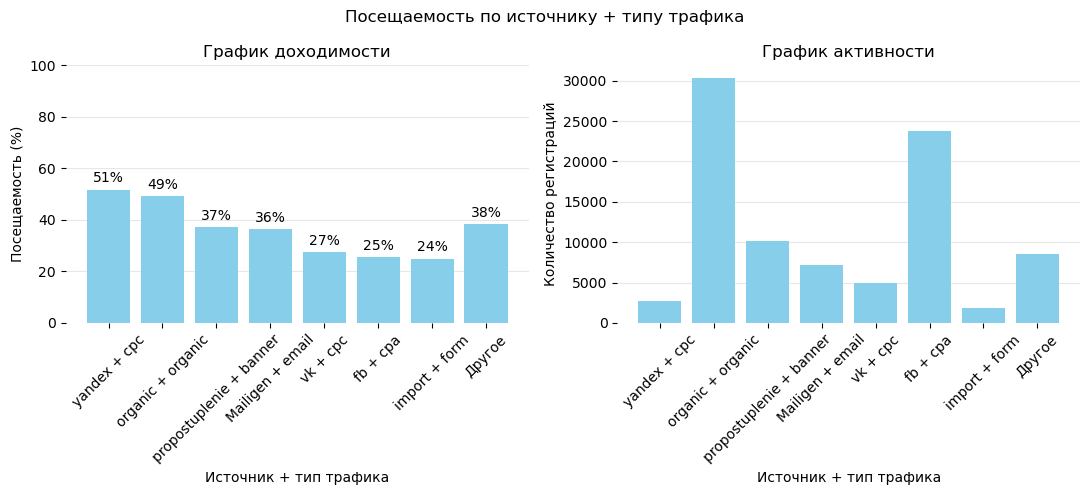

In [11]:
df = get_attendance(by=['utm_source', 'utm_medium'], df=new_reg)

df['utm_source + utm_medium'] = df['utm_source'] + ' + ' + df['utm_medium']
border = df['Registrations_count'].sum()*0.02

small_groups = df[df['Registrations_count'] < border].sum()
df = df[df['Registrations_count'] >= border].sort_values(by='Attendance', ascending=False)

df.loc[len(df)] = ['Другое', 'Другое', small_groups['Registrations_count'], small_groups['Visits_count'], 
                   small_groups['Visits_count'] / small_groups['Registrations_count'] * 100, 'Другое']

#display(df)
draw_attendance_hist(by='utm_source + utm_medium', df=df, xlabel='Источник + тип трафика', 
                     title='Посещаемость по источнику + типу трафика', save=SAVE_ALL_PICTS, rotate=True)

Может, в этом и проблема facebook. У него основной тип трафика cpa - плата за показы. Т.е. он заинтересован в показе рекламы как таковой (а вот превратится ли она в целевое действие - не очень).

- Лидер по доходимости: Наивысшую конверсию демонстрируют комбинации **yandex + cpc** (\~52%) и **organic + organic** (\~50%), значительно опережая остальные связки.
- Лидер по активности: Основную массу аудитории привлекают каналы **organic + organic** (более 30 тыс.) и **fb + cpa** (около 24 тыс.).
- Качество трафика: Связка *fb + cpa* обеспечивает большой поток регистраций, но имеет относительно низкую доходимость (~26%), в то время как *yandex + cpc* привлекает более целевую и конверсионную аудиторию при меньшем объеме.
- Гипотеза о природе различий: Модель cpa (оплата за показы) для fb стимулирует площадку максимизировать охваты, а не качество вовлечения.

### 4. Гипотеза 1: Возможно, посещаемость зависит от даты регистрации?  

In [12]:
def draw_lineplot(by, df, title='', xlabel = '', save=False, show=True):
    """
        График слева - количество регистраций по..
        График справа - доходимость по..
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.lineplot(data=df, x=by, y='Registrations_count', ax=axes[1])
    axes[1].set_ylabel('Количество регистраций')
    axes[1].set_title('График активности')
    
    sns.lineplot(data=df, x=by, y='Attendance', ax=axes[0])
    axes[0].set_ylabel('Посещаемость (%)')
    axes[0].set_title('График доходимости')

    if xlabel:
        axes[0].set_xlabel(xlabel)
        axes[1].set_xlabel(xlabel)

    fig.suptitle(title)
    plt.tight_layout()
    if save:
        plt.savefig(title + '.svg', format='svg', dpi=100, bbox_inches='tight')
    if show:
        plt.show()

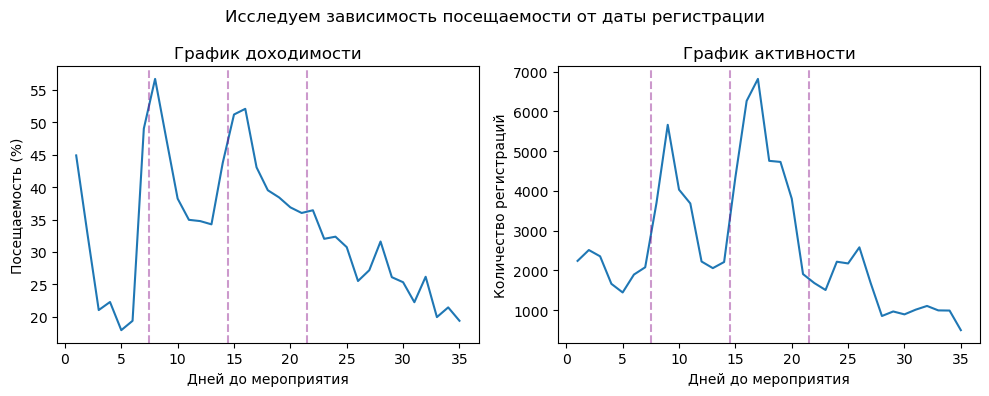

Корреляция Пирсона: -0.38, p-value = 0.023
Корреляция Спирмана: -0.37, p-value = 0.029

Отметим, что в данных наблюдается некоторая "цикличность" поведения с периодом в 7 дней.



In [13]:
df = get_attendance('DaysDiff', new_reg)
res = stats.pearsonr(df['DaysDiff'], df['Attendance'])
res2 = stats.spearmanr(df['DaysDiff'], df['Attendance'])

draw_lineplot('DaysDiff', df, title='Исследуем зависимость посещаемости от даты регистрации', xlabel='Дней до мероприятия', show=False)
fig = plt.gcf()
ax = fig.get_axes()
for i in range(1, 4):
    ax[0].axvline(x=0.5 + i*7, color='purple', linestyle='--', alpha=0.4)
    ax[1].axvline(x=0.5 + i*7 , color='purple', linestyle='--', alpha=0.4)
#Корреляция Пирсона: {res[0]:.2f}, p-value = {res[1]:.3f}\nКорреляция Спирмана: {res2[0]:.2f}, p-value = {res2[1]:.3f}\n
text = f"Корреляция Пирсона: {res[0]:.2f}, p-value = {res[1]:.3f}\nКорреляция Спирмана: {res2[0]:.2f}, p-value = {res2[1]:.3f}\n"
text += '\nОтметим, что в данных наблюдается некоторая "цикличность" поведения с периодом в 7 дней.\n'
#fig.text(0.5, -0.05, text, ha='center', va='center', wrap=True)
#plt.grid(alpha=0.3)

if SAVE_ALL_PICTS:
    plt.savefig('По дням без сглаживания.svg', format='svg', dpi=100, bbox_inches='tight')
plt.show()

print(text)

- Статистическая связь: Выявлена умеренная отрицательная связь между глубиной регистрации и доходимостью (корреляция Пирсона: **-0.38**, p-value = **0.023**; Спирмана: **-0.37**, p-value = **0.029**). Это подтверждает, что пользователи, регистрирующиеся заблаговременно, доходят до мероприятий реже.
- Эффект цикличности: На графиках прослеживается недельная цикличность (период в 7 дней, отмеченный вертикальными пунктирными линиями), связанная с недельными паттернами поведения пользователей.
- Динамика конверсии: Пики доходимости (до 55–56%) наблюдаются при регистрации за неделю до события, в то время как на больших горизонтах (30+ дней) показатель плавно снижается до 20%.

**Сгладим тренд по неделям!**  
Попробуем сгладить данные по неделям, чтобы учесть цикличные пики/спады

,N_of_week,Registrations_count,Visits_count,Attendance
0,0,14172,4336,30.595541
1,1,23548,10044,42.653304
2,2,32599,14194,43.541213
3,3,12684,3863,30.455692
4,4,6447,1498,23.235613


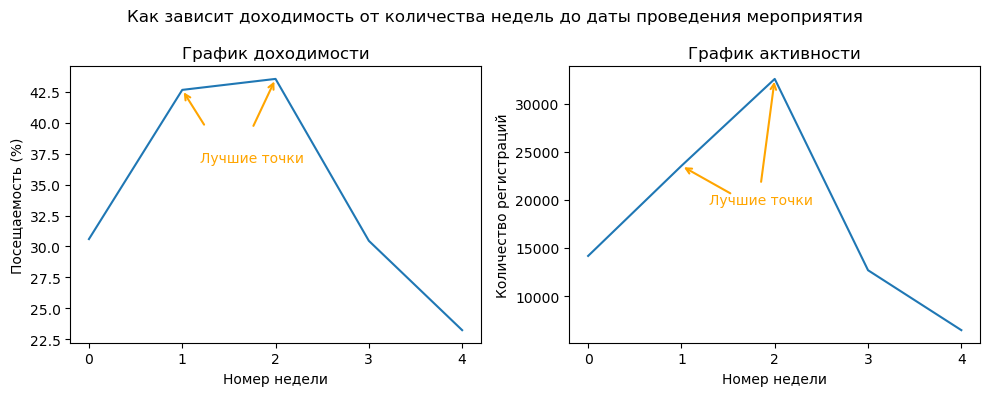

In [14]:
# Номер недели относительно даты проведения мероприятия:
new_reg['N_of_week'] = (new_reg['DaysDiff'] - 1) // 7
df = get_attendance(by='N_of_week', df=new_reg)

res = stats.pearsonr(df['N_of_week'].astype(int), df['Attendance'])
res2 = stats.spearmanr(df['N_of_week'].astype(int), df['Attendance'])

df['N_of_week'] = df['N_of_week'].astype(int).astype(str)
display(df)
draw_lineplot(by='N_of_week', df=df, title='Как зависит доходимость от количества недель до даты проведения мероприятия', xlabel='Номер недели', show=False)
df['N_of_week'] = df['N_of_week'].astype(int)
fig = plt.gcf()
ax = fig.get_axes()

# стрелочки для правого графика
x, y = df.iloc[2, [0, 3]].values
ax[0].annotate('', xy=(x, y), xytext=(x-0.25, y-4),arrowprops=dict(arrowstyle='->', lw=1.5, color='orange'))
ax[0].text(x-0.25, y - 6.7, 'Лучшие точки', ha='center', fontsize=10, color='orange')
x, y = df.iloc[1, [0, 3]].values
ax[0].annotate('', xy=(x, y), xytext=(x+0.25, y-3),arrowprops=dict(arrowstyle='->', lw=1.5, color='orange'))

# стрелочки для левого графика
x, y = df.iloc[2, [0, 1]].values
ax[1].annotate('', xy=(x, y), xytext=(x-0.15, y-11000),arrowprops=dict(arrowstyle='->', lw=1.5, color='orange'))
ax[1].text(x - 0.15, y - 13000, 'Лучшие точки', ha='center', fontsize=10, color='orange')
x, y = df.iloc[1, [0, 1]].values
ax[1].annotate('', xy=(x, y), xytext=(x+0.55, y-3000),arrowprops=dict(arrowstyle='->', lw=1.5, color='orange'))

# вывод фигуры
#text=f'Корреляция Пирсона: {res[0]:.2f}, p-value = {res[1]:.3f}\nКорреляция Спирмана: {res2[0]:.2f}, p-value = {res2[1]:.3f}'
#fig.text(0.5, -0.05, text, ha='center', va='center', wrap=True)
if SAVE_ALL_PICTS:
    plt.savefig('По дням после сглаживания.svg', format='svg', dpi=200, bbox_inches='tight')
plt.show()

Т.к. pvalue большое, нулевая гипотеза не отвергается т.е. строгой линейной/монотонной зависимости установить не удалось.

- Агрегация по неделям: При переходе к недельному масштабу сглаживаются суточные колебания, вырисовывая общую динамику.
- Пик эффективности: Максимальные показатели доходимости (42–43.5%) и наибольший объем регистраций достигаются при регистрации за **1–2 недели** (т.е. 7-20 дней до начала) до проведения мероприятия.
- Зоны спада: На нулевой неделе (непосредственно перед событием) и на дальних горизонтах (3–4 недели) наблюдается заметное падение как конверсии в посещение, так и общего числа регистраций.

### 4. Гипотеза 2: Возможно, посещаемость зависит дня недели?

In [15]:
# 0 - Понедельник
# 6 - Воскресение
new_reg['Weekday'] = new_reg['Created'].dt.weekday.astype(int)

,Weekday,Registrations_count,Visits_count,Attendance
0,0,6725,2252,33.486989
1,1,8865,2853,32.182741
2,2,11231,3803,33.861633
3,3,12435,4434,35.657419
4,4,15224,5897,38.734892
5,5,13858,6920,49.935056
6,6,6940,3440,49.567723


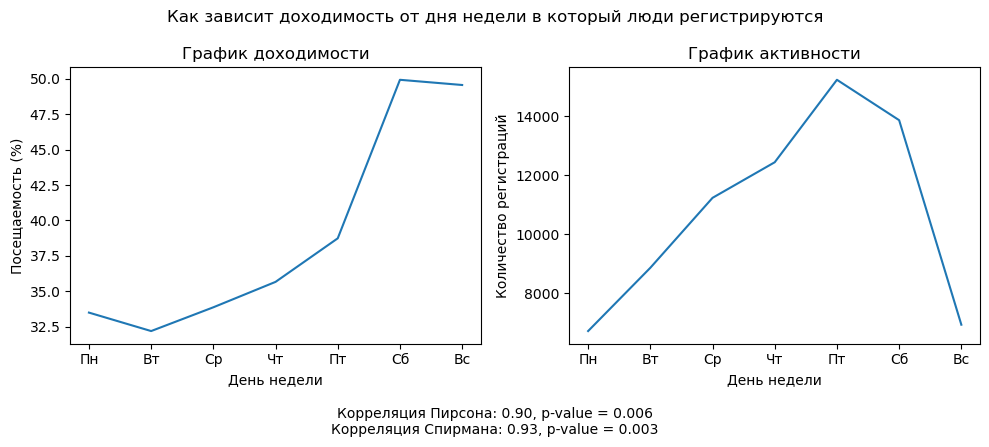

In [16]:
# Почему мы берем только дни через неделю и более после мероприятий объяснено в выводах ниже
df = get_attendance(by='Weekday', df=new_reg[(new_reg['DaysDiff'] > 7)])
display(df)
res = stats.pearsonr(df['Weekday'], df['Attendance'])
res2 = stats.spearmanr(df['Weekday'], df['Attendance'])

# цифры переводим в дни недели
days_dict = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
df['Weekday'] = df['Weekday'].map(days_dict)
draw_lineplot(by='Weekday', df=df, title='Как зависит доходимость от дня недели в который люди регистрируются', xlabel='День недели',  save=False, show=False)

fig = plt.gcf()
text=f'Корреляция Пирсона: {res[0]:.2f}, p-value = {res[1]:.3f}\nКорреляция Спирмана: {res2[0]:.2f}, p-value = {res2[1]:.3f}'
fig.text(0.5, -0.05, text, ha='center', va='center', wrap=True)

if SAVE_ALL_PICTS:
    plt.savefig('Как зависит доходимость от дня недели в который люди регистрируются.svg', dpi=100, bbox_inches='tight')
plt.show() 

- Статистическая связь: Обнаружена очень сильная связь (корреляция Пирсона: **0.90**, p-value = **0.006**; Спирмана: **0.93**, p-value = **0.003**).
- Методология: Для чистоты эксперимента отсечены регистрации менее чем за неделю до события, чтобы исключить искажения из-за близости даты.
- Пики активности и конверсии: Максимальный интерес пользователей фиксируется в **пятницу и субботу** (до 15 тыс. регистраций), а пик доходимости достигается в **субботу и воскресенье** (почти 50%), что делает выходные дни оптимальными для рекламных кампаний.

### Сравнительный анализ каналов привлечения (Facebook, Organic, Yandex)

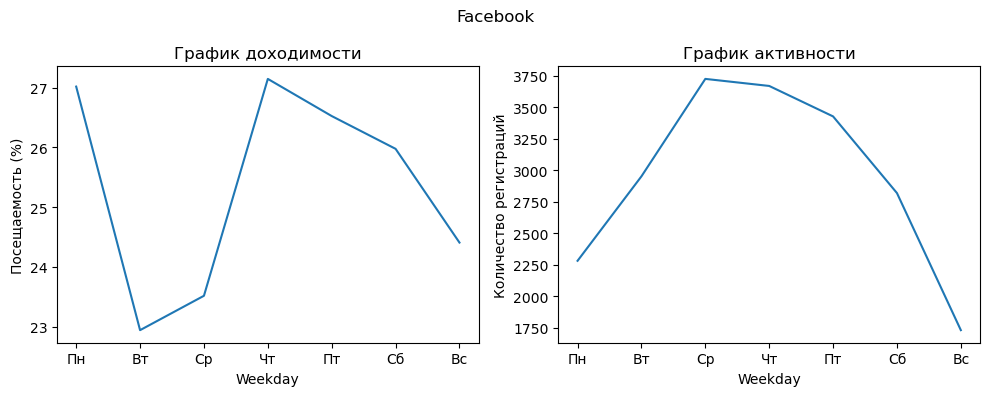

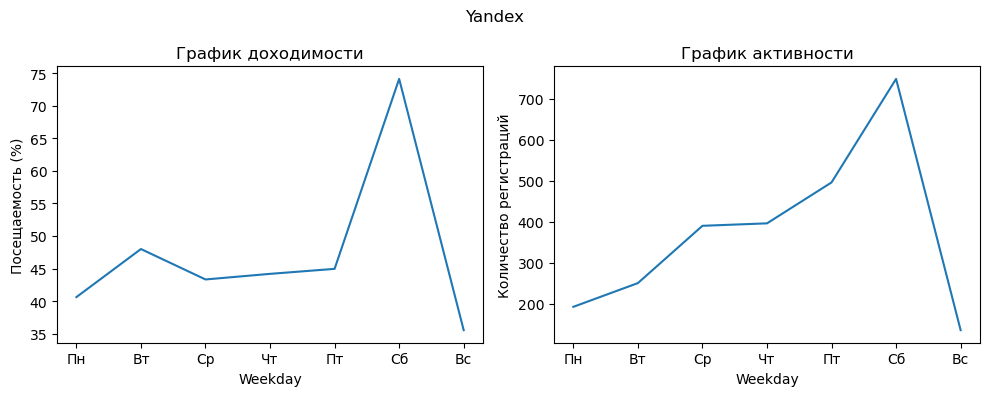

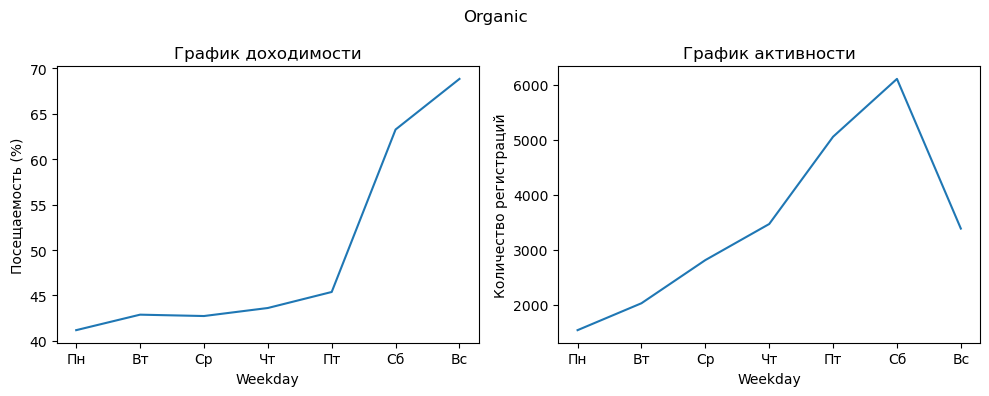

In [17]:
df = get_attendance(by='Weekday', df=new_reg[(new_reg['DaysDiff'] > 7) & (new_reg['utm_source'] == 'fb')])
df['Weekday'] = df['Weekday'].map(days_dict)
draw_lineplot(by='Weekday', df=df, title='Facebook', save=SAVE_ALL_PICTS)

df = get_attendance(by='Weekday', df=new_reg[(new_reg['DaysDiff'] > 7) & (new_reg['utm_source'] == 'yandex')])
df['Weekday'] = df['Weekday'].map(days_dict)
draw_lineplot(by='Weekday', df=df, title='Yandex', save=SAVE_ALL_PICTS)

df = get_attendance(by='Weekday', df=new_reg[(new_reg['DaysDiff'] > 7) & (new_reg['utm_source'] == 'organic')])
df['Weekday'] = df['Weekday'].map(days_dict)
draw_lineplot(by='Weekday', df=df, title='Organic', save=SAVE_ALL_PICTS)

- Эффективность рекламных каналов: *Facebook* генерирует большой объем регистраций (пик в будни: Ср-Чт), но показывает стабильно среднюю и низкую доходимость (в пределах 23–27%). *Yandex*, напротив, привлекает меньше пользователей, но попадает в целевую аудиторию: пик его активности и конверсии приходится на субботу (доходимость до 74%).
- Органический трафик (*Organic*): Демонстрирует отличные показатели — пики регистраций и максимальная доходимость (до 65–69%) фиксируются в выходные дни (суббота-воскресенье).
- Поведенческие особенности и таргетинг: Ключевую роль играют возможности алгоритмов конкретной площадки. Продвинутые алгоритмы поиска и контекстного таргетинга у *Yandex* позволяют точнее учитывать историю запросов и намерения пользователей, привлекая аудиторию с высокой вероятностью доходимости.

### Проверка гипотезы: Facebook статистически значимо хуже других каналов?

**Методология**:

Проведено z-тестирование пропорций для ключевых массовых мероприятий (ID 3, 17, 20), где Facebook сравнивался с остальными источниками.  
$H_0$: конверсия Facebook равна или выше,  
$H_1$: конверсия Facebook ниже.

In [18]:
def prop_test_conversions(df, metric_col, ab_group_col, pairs_list,
                           alternative='two-sided', ci=False, corrected_ci=0.95):
    from statsmodels.stats.proportion import test_proportions_2indep
    """
    Z-тест разницы пропорций

    df: датафрейм,
    metric_col: колонка-индикатор, например 'Was' (дошел/не дошел),
    ab_group_col: колонка с группой сравнения, например 'utm_source',
    pairs_list: список пар,
    alternative: 'two-sided' | 'smaller' | 'larger',
    ci: считать ли доверительный интервал,
    corrected_ci : уровень ДИ — ДОЛЖЕН уже включать поправку на множественное сравнение (например 1 - alpha/n_pairs).
    Возвращает датафрейм с числовыми колонками.
    """
    rows = []
    for group0, group1 in pairs_list:
        sub0 = df.loc[df[ab_group_col] == group0, metric_col]
        sub1 = df.loc[df[ab_group_col] == group1, metric_col]
        num0, denom0 = sub0.sum(), sub0.count()
        num1, denom1 = sub1.sum(), sub1.count()

        if denom0 == 0 or denom1 == 0:
            print(f"⚠️ Пропускаю {group0} vs {group1}: пустая группа")
            continue

        p0, p1 = num0 / denom0, num1 / denom1

        r = test_proportions_2indep(
            num0, denom0, num1, denom1,
            value=0, method='wald', compare='diff',
            alternative=alternative, correction=True, return_results=True
        )
        se = np.sqrt(r.variance)
        delta = p1 - p0
        delta_pct = (p1 / p0 - 1) * 100 if p0 != 0 else np.nan

        row = {
            'group0': group0, 'group1': group1,
            'statistic': r.statistic, 'pvalue': r.pvalue,
            'p0': p0, 'p1': p1, 'n0': denom0, 'n1': denom1,
            'delta': delta, 'delta_pct': delta_pct,
        }

        if ci:
            z = stats.norm.ppf((1 + corrected_ci) / 2)
            lb, ub = delta - z * se, delta + z * se
            row['lb'], row['ub'] = lb, ub
            row['lb_pct'] = lb / p0 * 100 if p0 != 0 else np.nan
            row['ub_pct'] = ub / p0 * 100 if p0 != 0 else np.nan

        rows.append(row)

    return pd.DataFrame(rows)

In [19]:
alpha = 0.05
events_for_fb_test = [3, 17, 20]  # самые массовые и разнесённые по времени
sources_to_compare = ['organic', 'propostuplenie', 'yandex', 'vk', 'Mailigen']

all_results = []

for event_id in events_for_fb_test:
    sub = new_reg[
        (new_reg['EventID'] == event_id) &
        (new_reg['utm_source'].isin(['fb'] + sources_to_compare))
    ].copy()
    sub['Was'] = sub['VisitID'].notna().astype(int)

    pairs = [('fb', src) for src in sources_to_compare]
    n_pairs = len(pairs)
    corrected_ci = 1 - alpha / n_pairs  # поправка Бонферрони и на ДИ тоже

    res = prop_test_conversions(
        sub, metric_col='Was', ab_group_col='utm_source',
        pairs_list=pairs, alternative='smaller',  # H1: доходимость fb ниже
        ci=True, corrected_ci=corrected_ci
    )
    reject, pval_corr, _, _ = multipletests(res['pvalue'], alpha=alpha, method='bonferroni')
    res['pvalue_corrected'] = pval_corr
    res['reject_h0'] = reject
    res['EventID'] = event_id
    all_results.append(res)

fb_results = pd.concat(all_results, ignore_index=True)
display(fb_results[['EventID', 'group1', 'p0', 'p1', 'delta_pct',
                     'pvalue_corrected', 'reject_h0']])

,EventID,group1,p0,p1,delta_pct,pvalue_corrected,reject_h0
0,3,organic,0.245745,0.490665,99.663910,0.000000e+00,True
1,3,propostuplenie,0.245745,0.343404,39.739929,7.621578e-36,True
2,3,yandex,0.245745,0.486000,97.765651,4.999424e-67,True
3,3,vk,0.245745,0.357597,45.515138,3.698453e-31,True
4,3,Mailigen,0.245745,0.370561,50.790556,1.216806e-42,True
5,17,organic,0.314494,0.566206,80.037391,3.123921e-233,True
6,17,propostuplenie,0.314494,0.442564,40.722799,7.621096e-33,True
7,17,yandex,0.314494,0.632856,101.229998,1.042120e-77,True
8,17,vk,0.314494,0.371257,18.049278,4.338415e-06,True
9,17,Mailigen,0.314494,0.359532,14.320836,4.537573e-05,True


- Подтвержденные различия: Нулевая гипотеза успешно отвергнута ($p < 0.05$) для каналов **Organic**, **Yandex**, **propostuplenie** и **Mailigen** на большинстве крупных ивентов. Их доходимость статистически значимо выше, чем у Facebook (прирост составляет от ~40% до более чем 100%).
- Результаты по VK: Для VK гипотеза подтверждается не везде (на исключенных мероприятиях различия незначимы), поэтому канал отнесен к спорным и требует осторожности в интерпретации.

### 4. Гипотеза 3: Возможно, есть определенные часы, в которые люди лучше обращаются в участников мероприятий?
Это вопрос сохранения денег: сократить время показа рекламы до самых релевантных часов.

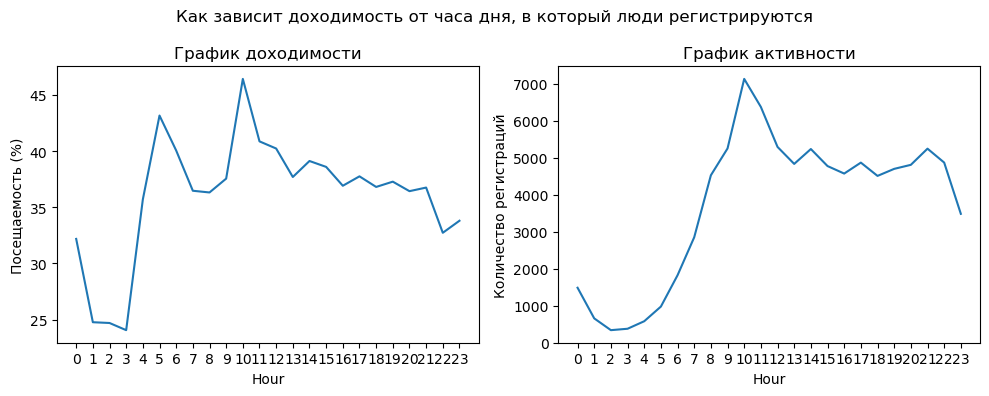

In [20]:
new_reg['Hour'] = new_reg['Created'].dt.hour.astype(int)
df = get_attendance(by='Hour', df=new_reg)

#display(df)
df['Hour'] = df['Hour'].astype(str) 
draw_lineplot(by='Hour', df=df, title='Как зависит доходимость от часа дня, в который люди регистрируются', save=SAVE_ALL_PICTS)

In [21]:
# Корреляция (Пирсон - Кендалл - Спирман):
# 0.32 0.015 0.16
# линейная/мотононная сязь статистически незначима
print(stats.pearsonr(df['Hour'].astype(int), df['Attendance']))
print(stats.spearmanr(df['Hour'].astype(int), df['Attendance']))

PearsonRResult(statistic=np.float64(0.3184306787043912), pvalue=np.float64(0.12939294583485952))
SignificanceResult(statistic=np.float64(0.18086956521739128), pvalue=np.float64(0.39767420741690407))


- Оптимальный диапазон времени: Наиболее эффективный интервал для привлечения пользователей — с **9:00 до 21:00**, когда наблюдаются стабильно высокие показатели активности и конверсии.
- Лидер по активности: Пик как по количеству регистраций (более 7 тыс.), так и по доходимости (до 46–47%) приходится на утренние часы — **10:00–11:00**.
- Ночные часы: В период с 0:00 до 4:00 активность минимальна, а конверсия существенно проседает, что делает ночное время бесперспективным для рекламных показов.

### 5. Исследование мероприятий по отдельности

In [24]:
def get_analyz_by(dataframe, ids=[3, 17], palette='pastel'):
    """Функция вывода графиков по анализу мероприятий друг с другом
        df - датафрейм
        ids - список id мероприятий для сравнения
    """
    # график первый:
    df = get_attendance(by='EventID', df=dataframe[dataframe['EventID'].isin(ids)])
    df['EventID'] = df['EventID'].astype(str)
    #avg_attendance = df['Attendance'].mean()
    avg_attendance = df['Visits_count'].sum() / df['Registrations_count'].sum() * 100

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].set_title('Доходимость')
    axes[1].set_title('Интерес')
    axes[0].axhline(y=avg_attendance, color='red', linestyle='--', label=f'Средняя доходимость: {avg_attendance:.2f}%')
    sns.barplot(df, x='EventID', y='Attendance', color='skyblue', ax=axes[0])
    axes[0].set_ylim(0, 100)
    sns.barplot(df, x='EventID', y='Registrations_count', color='skyblue', ax=axes[1])
    plt.tight_layout()
    if SAVE_ALL_PICTS:
        plt.savefig('p1.png', format='png', dpi=100, bbox_inches='tight')
    plt.show()

    # график второй:
    df = get_attendance(by=['Who', 'EventID'], df=dataframe[(dataframe['Who'] != 'Другое') & (dataframe['EventID'].isin(ids))])
    parents_avg = df[df['Who'] == 'Родитель']['Visits_count'].sum() / df[df['Who'] == 'Родитель']['Registrations_count'].sum() * 100
    children_avg = df[df['Who'] == 'Ученик']['Visits_count'].sum() / df[df['Who'] == 'Ученик']['Registrations_count'].sum() * 100

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].set_title('Доходимость')
    axes[1].set_title('Интерес')
    sns.barplot(df, x='Who', y='Attendance', hue='EventID', palette=palette, ax = axes[0])
    axes[0].set_ylim(0, 100)
    axes[0].axhline(y=parents_avg, xmax=0.5, color='blue', linestyle='--')
    axes[0].axhline(y=children_avg, xmin=0.5, color='blue', linestyle='--')
    axes[0].hlines(y=0, xmin=0, xmax=0,  colors='blue', linestyles='--', label=f'Средняя для каждой категории')
    axes[0].legend()
    sns.barplot(df, x='Who', y='Registrations_count', hue='EventID', palette=palette, ax=axes[1])
    plt.tight_layout()
    if SAVE_ALL_PICTS:
        plt.savefig('p2.png', format='png', dpi=100, bbox_inches='tight')
    plt.show()

    # график третий:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].set_title('Доходимость')
    axes[1].set_title('Интерес')
    df = get_attendance(by=['Class', 'EventID'], df=dataframe[dataframe['EventID'].isin(ids)])
    df['Class'] = df['Class'].astype(int).astype(str)
    sns.barplot(df, x='Class', y='Attendance', hue='EventID', palette=palette, ax=axes[0])
    axes[0].set_ylim(0, 100)
    for i in range (11):
        avg = df[df['Class'] == str(i + 1)]['Visits_count'].sum() / df[df['Class'] == str(i + 1)]['Registrations_count'].sum() * 100
        axes[0].axhline(y=avg, xmin = 1/24 + i*1/12, xmax=1/24 + (i+1)/12, color='blue', linestyle='--')
    axes[0].hlines(y=0, xmin=0, xmax=0,  colors='blue', linestyles='--', label=f'Средняя для каждого класса')
    sns.barplot(df, x='Class', y='Registrations_count', hue='EventID', palette=palette, ax=axes[1])
    axes[0].legend()
    plt.tight_layout()
    if SAVE_ALL_PICTS:
        plt.savefig('p3.png', format='png', dpi=100, bbox_inches='tight')
    plt.show()

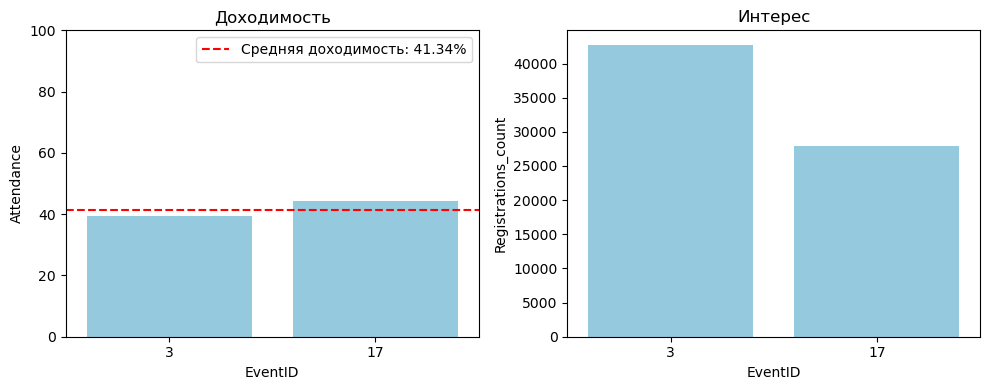

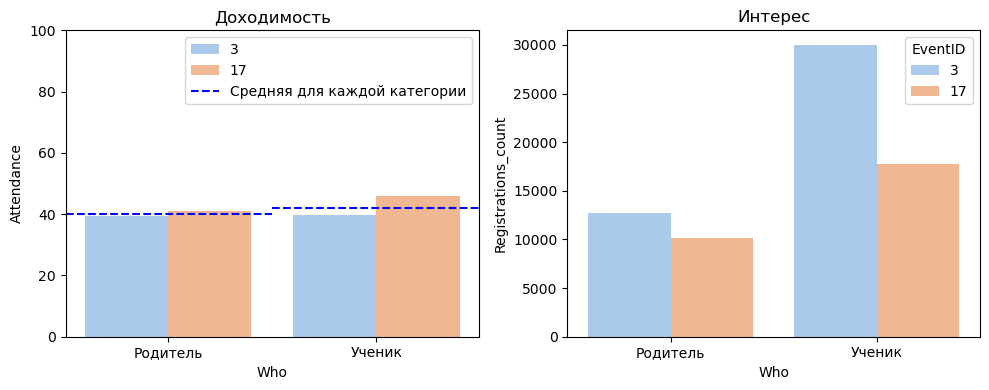

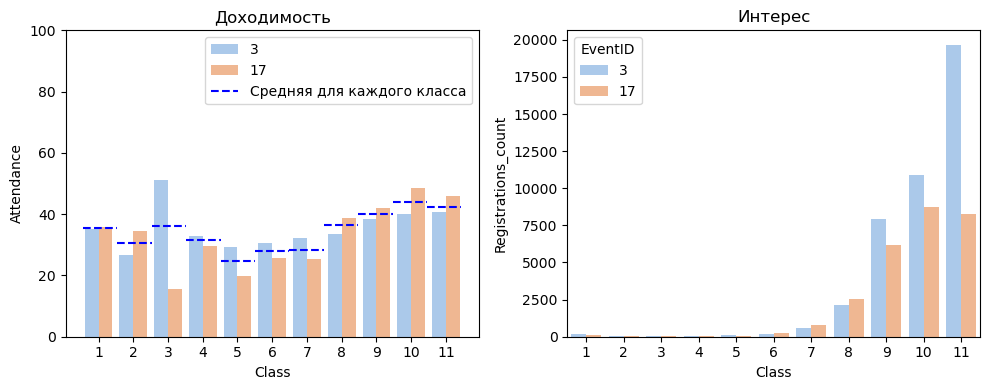

In [25]:
get_analyz_by(new_reg, [3, 17])

#### Сравнение мероприятий (ID 3 и ID 17) в динамике

- Общие показатели: Мероприятие **ID 3** собрало значительно большую аудиторию по числу регистраций (около 42 тыс. против 28 тыс. у ID 17), однако мероприятие **ID 17** превосходит его по доходимости, слегка превышая среднюю линию по проекту (~41.3%).
- Разрез по категориям (Родители / Ученики): Структура аудитории у обоих событий схожа — основную массу составляют ученики. При этом у мероприятия ID 17 доходимость по категории «Ученик» выше и достигает почти 46%.
- Разрез по классам: Сравнительный анализ показывает, что у события ID 17 конверсия в старших классах (особенно в 10–11) держится на более высоком уровне, несмотря на меньшее абсолютное число регистраций по сравнению с ID 3.

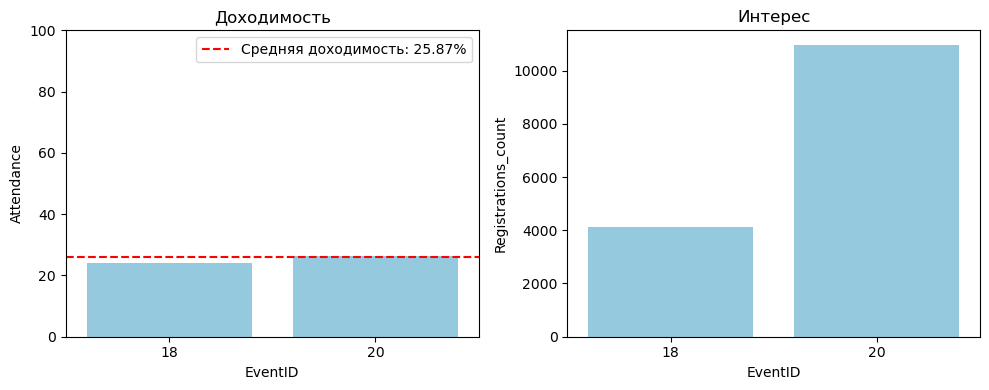

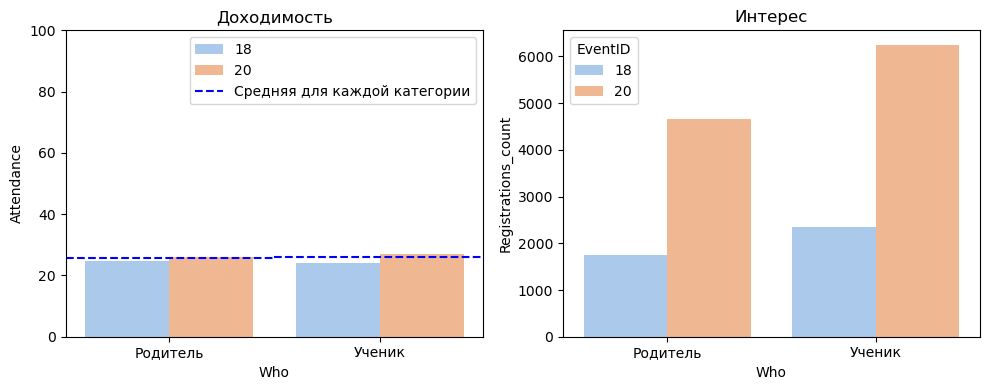

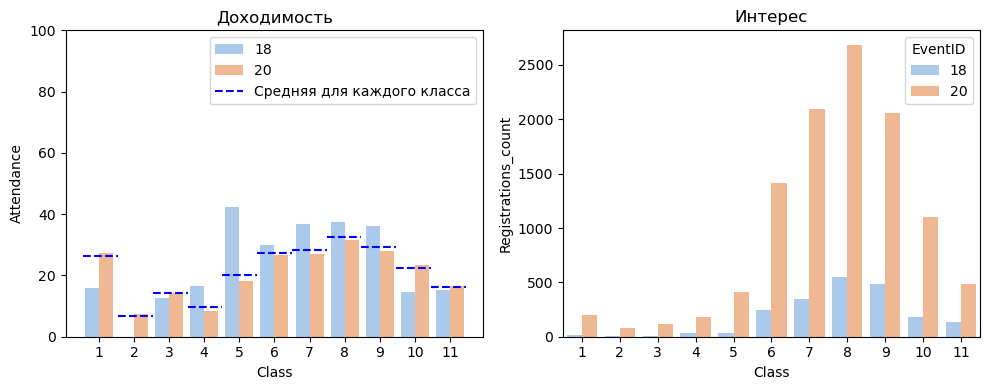

In [26]:
get_analyz_by(new_reg, [18, 20])

#### Сравнение мероприятий (ID 18 и ID 20) в динамике

- Общие показатели: Мероприятие **ID 20** значительно превосходит **ID 18** по количеству регистраций (\~11 тыс. против \~4 тыс.), при этом доходимость у обоих событий держится примерно на одном уровне, близком к средней линии (\~25.87%).
- Разрез по категориям (Родители / Ученики): Структура аудитории по категориям пропорциональна: мероприятие ID 20 собирает больше участников как среди родителей, так и среди учеников, сохраняя равные показатели конверсии для обеих групп.
- Разрез по классам: Сравнение по классам показывает, что ID 20 уверенно лидирует по объему регистраций во всех параллелях (особенно в 7–9 классах), в то время как по доходимости наблюдаются разнонаправленные локальные пики у обоих событий без резкого доминирования одного из них.

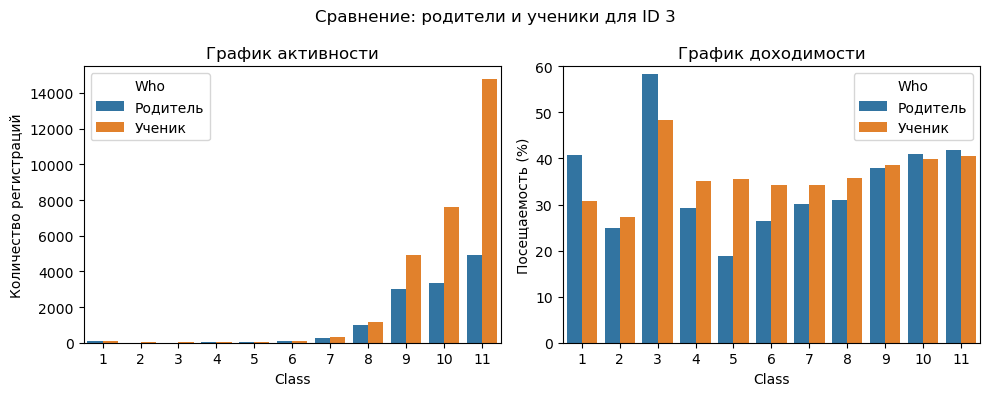

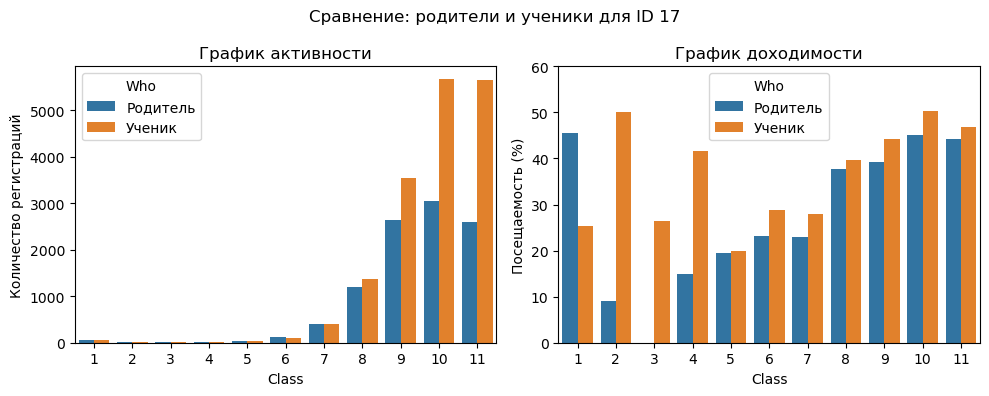

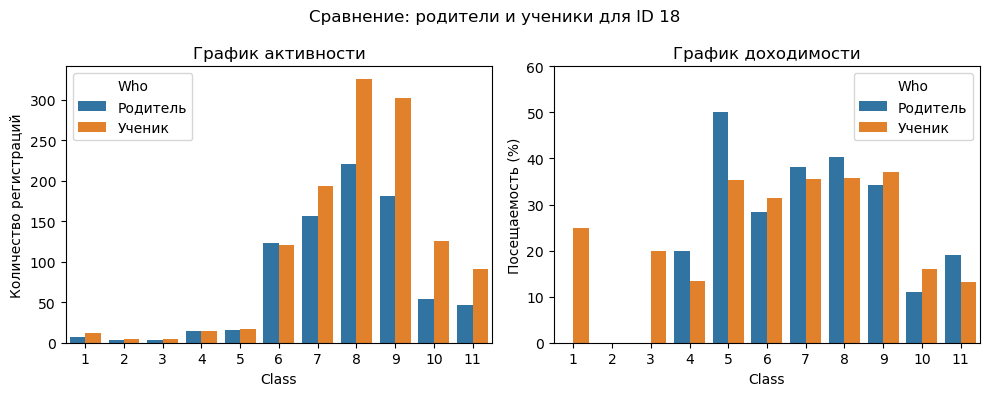

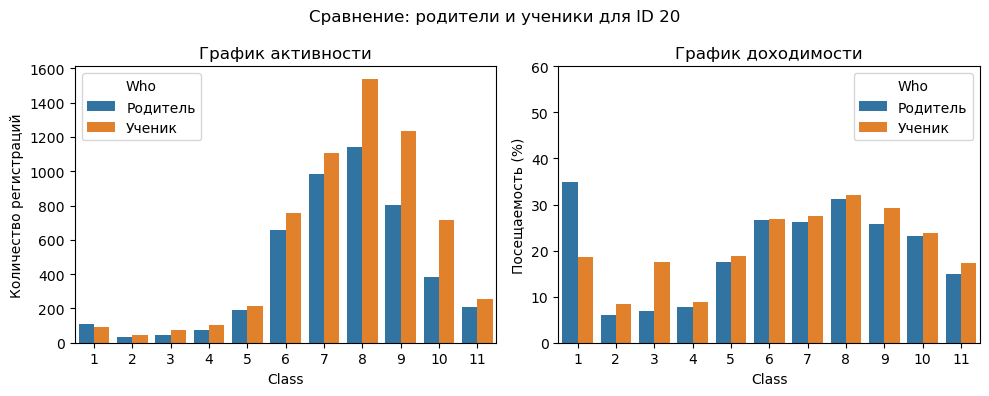

In [29]:
def plot_class_comparison(event_ids, save=SAVE_ALL_PICTS):
    """
    event_ids: ID мероприятия или список ID
    """
    
    if isinstance(event_ids, int):
        event_ids = [event_ids]
    
    for event_id in event_ids:
        df = get_attendance(
            by=['Who', 'Class'], 
            df=new_reg[(new_reg['Who'] != 'Другое') & (new_reg['EventID'].isin([event_id]))]
        )
        df = df[df['Class'] <= 11]
        df['Class'] = df['Class'].astype(int).astype(str)
        
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        
        sns.barplot(df, x="Class", y="Registrations_count", hue="Who", ax=axes[0])
        axes[0].set_ylabel('Количество регистраций')
        axes[0].set_title('График активности')
        
        sns.barplot(df, x="Class", y="Attendance", hue="Who", ax=axes[1])
        axes[1].set_ylabel('Посещаемость (%)')
        axes[1].set_title('График доходимости')
        axes[1].set_ylim(0, 60)
        
        fig.suptitle(f'Сравнение: родители и ученики для ID {event_id}')
        plt.tight_layout()
        
        if save:
            plt.savefig(f'Родители и ученики сравнение_ID_{event_id}.png', format='png', dpi=100, bbox_inches='tight')
        
        plt.show()

plot_class_comparison([3, 17, 18, 20])

### Итоговый анализ динамики мероприятий (в хронологическом порядке: 15 -> 3 -> 17 -> 18 -> 20)

- Эволюция по мере проведения: Первое мероприятие (**ID 15**) предположительно столкнулось с организационными трудностями и низким интересом из-за отсутствия опыта и информированности аудитории. Пик популярности пришелся на осенние мероприятия (**ID 3** и **ID 17**), где доминировали ученики выпускных классов.
- Влияние экзаменационного периода: На поздних этапах (мероприятия **ID 18** и **ID 20**) наблюдается спад активности старшеклассников, что связано с подготовкой к экзаменам (ОГЭ/ЕГЭ в феврале) и возможным исчерпанием локального спроса при очном формате в одном районе.
- Поведенческие особенности аудитории: Ученики проявляют больший интерес к тематике мероприятий, однако общая доходимость у учеников и родителей находится примерно на одном уровне. Младшие классы показывают неплохую конверсию, но их абсолютное число слишком мало для масштабных кампаний.


### Рекомендации

- Старт сезона (осень): Фокусироваться на привлечении старшеклассников в начале учебного года, так как они демонстрируют максимальную активность и заинтересованность.
- Середина учебного года (февраль–март): Переориентировать рекламные усилия на младшие параллели будущих выпускников (**7–8 и 10 классы**), у которых есть свободное время и формируется запрос на выбор будущей траектории обучения.
- Отказ от неэффективных сегментов: Исключить младшие классы из приоритетного таргетинга из-за критически малого объема аудитории.

In [33]:
def compare_events(event_id1, event_id2, metric='Attendance', top_n=6, save=SAVE_ALL_PICTS):
    """
    Сравнивает два мероприятия по источникам трафика.
    event_id1: ID первого мероприятия
    event_id2: ID второго мероприятия
    metric: 'Attendance' — доходимость, 'Registrations_count' — активность
    top_n: Количество топ-каналов для отображения (по умолчанию 5)
    
    Возвращает датафреймы для каждого мероприятия (топ-N + Другое)
    """
    # Подготовка данных для первого мероприятия
    df_event_1 = new_reg[new_reg['ExhibitionID'] == event_id1].copy()
    df_1 = get_attendance(by='utm_source', df=df_event_1)
    
    border_1 = df_1['Registrations_count'].sum() * 0.025
    df_1 = df_1[df_1['Registrations_count'] >= border_1]
    df_1 = df_1.sort_values(by='Attendance', ascending=False)
    top_df_1 = df_1.iloc[:top_n].copy()
    
    # Объединяем остальные в "Другое"
    if len(df_1) > top_n + 1:
        other_groups_1 = df_1.iloc[top_n:].sum()
        other_row_1 = pd.DataFrame({
            'utm_source': ['Другое'],
            'Registrations_count': [other_groups_1['Registrations_count']],
            'Visits_count': [other_groups_1['Visits_count']],
            'Attendance': [other_groups_1['Visits_count'] / other_groups_1['Registrations_count'] * 100]
        })
        top_df_1 = pd.concat([top_df_1, other_row_1], ignore_index=True)
    
    top_df_1 = top_df_1.sort_values(by='Attendance', ascending=False)
    avg_attendance_1 = df_1['Attendance'].mean()
    
    # Подготовка данных для второго мероприятия
    df_event_2 = new_reg[new_reg['ExhibitionID'] == event_id2].copy()
    df_2 = get_attendance(by='utm_source', df=df_event_2)
    
    border_2 = df_2['Registrations_count'].sum() * 0.025
    df_2 = df_2[df_2['Registrations_count'] >= border_2]
    df_2 = df_2.sort_values(by='Attendance', ascending=False)
    top_df_2 = df_2.iloc[:top_n].copy()
    
    # Объединяем остальные в "Другое"
    if len(df_2) > top_n + 1:
        other_groups_2 = df_2.iloc[top_n:].sum()
        other_row_2 = pd.DataFrame({
            'utm_source': ['Другое'],
            'Registrations_count': [other_groups_2['Registrations_count']],
            'Visits_count': [other_groups_2['Visits_count']],
            'Attendance': [other_groups_2['Visits_count'] / other_groups_2['Registrations_count'] * 100]
        })
        top_df_2 = pd.concat([top_df_2, other_row_2], ignore_index=True)
    
    top_df_2 = top_df_2.sort_values(by='Attendance', ascending=False)
    avg_attendance_2 = df_2['Attendance'].mean()
    
    # Строим графики
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    # Левый график
    colors_1 = ['skyblue' if x != 'Другое' else 'lightgray' for x in top_df_1['utm_source']]
    bars_1 = axes[0].bar(top_df_1['utm_source'], top_df_1[metric], color=colors_1)
    
    if metric == 'Attendance':
        axes[0].axhline(y=avg_attendance_1, color='red', linestyle='--', label=f'Средняя: {avg_attendance_1:.2f}%')
        axes[0].set_title(f'Посещаемость для event id={event_id1}')
        axes[0].set_ylabel('Доходимость (%)')
    else:
        axes[0].set_title(f'Активность для event id={event_id1}')
        axes[0].set_ylabel('Количество регистраций')
    
    axes[0].set_xlabel('Источник трафика')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    axes[0].tick_params(axis='x', rotation=45)
    if metric == 'Attendance':
        axes[0].legend()
    
    # Правый график
    colors_2 = ['lightgreen' if x != 'Другое' else 'lightgray' for x in top_df_2['utm_source']]
    bars_2 = axes[1].bar(top_df_2['utm_source'], top_df_2[metric], color=colors_2)
    
    if metric == 'Attendance':
        axes[1].axhline(y=avg_attendance_2, color='red', linestyle='--', label=f'Средняя: {avg_attendance_2:.2f}%')
        axes[1].set_title(f'Посещаемость для event id={event_id2}')
    else:
        axes[1].set_title(f'Активность для event id={event_id2}')
    
    axes[1].set_xlabel('Источник трафика')
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    axes[1].tick_params(axis='x', rotation=45)
    if metric == 'Attendance':
        axes[1].legend()
    
    title_map = {
        'Attendance': 'Сравнение доходимости по источникам трафика',
        'Registrations_count': 'Сравнение активности по источникам трафика'
    }
    fig.suptitle(f'{title_map.get(metric, "Сравнение")} (ID {event_id1} vs {event_id2})', fontsize=16)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    if save:
        plt.savefig(f'compare_events_{event_id1}_vs_{event_id2}.png', format='png', dpi=100, bbox_inches='tight')
    
    plt.show()
    
    return top_df_1, top_df_2

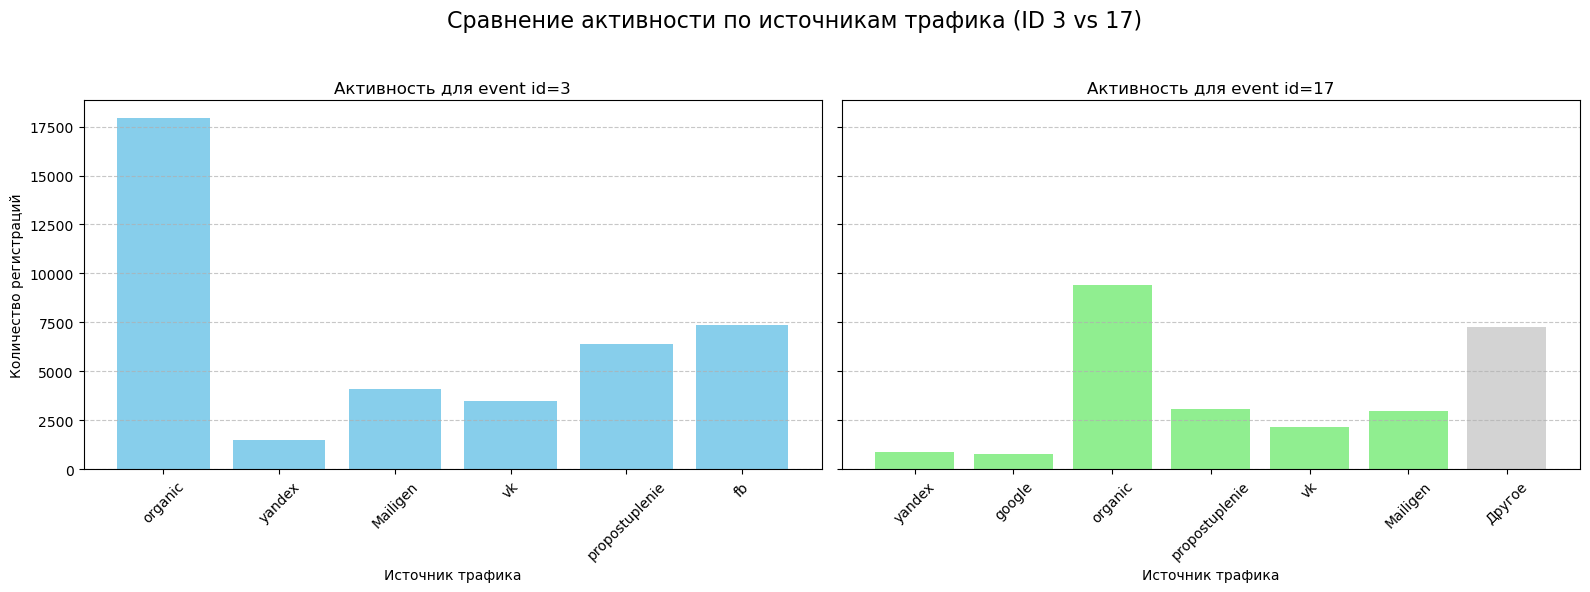

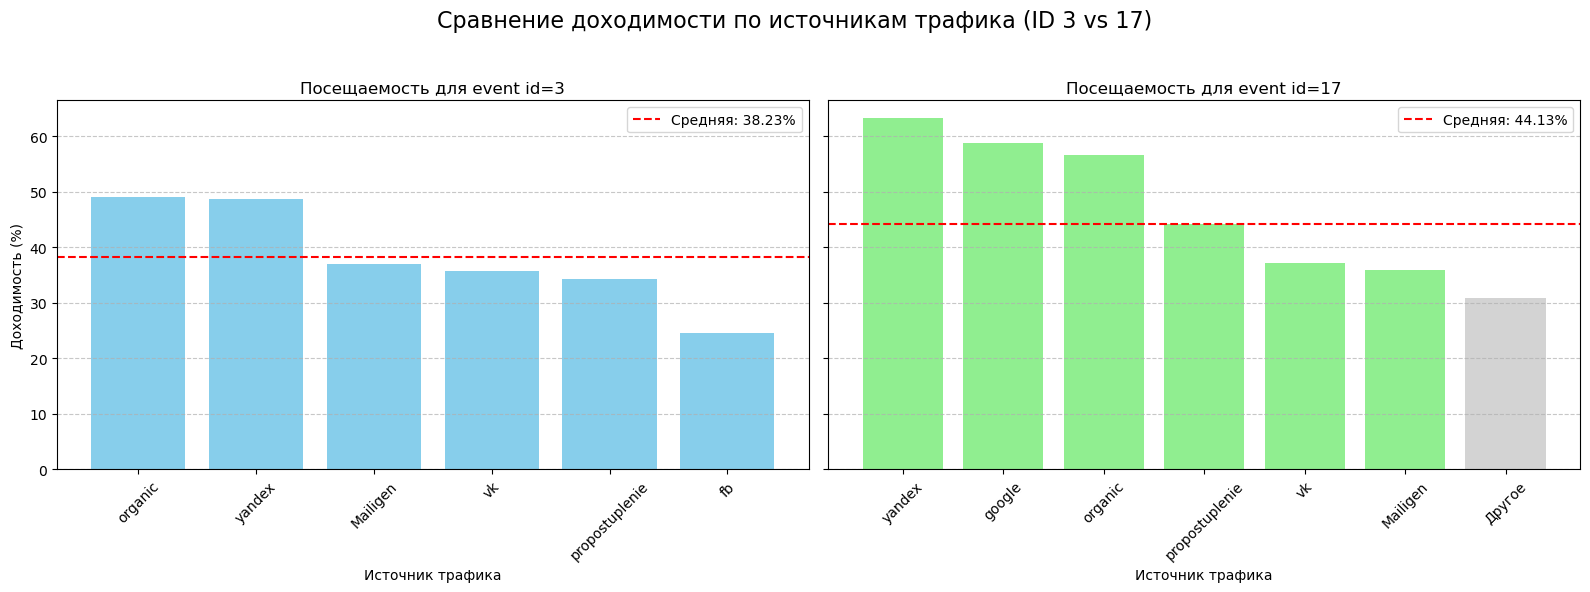

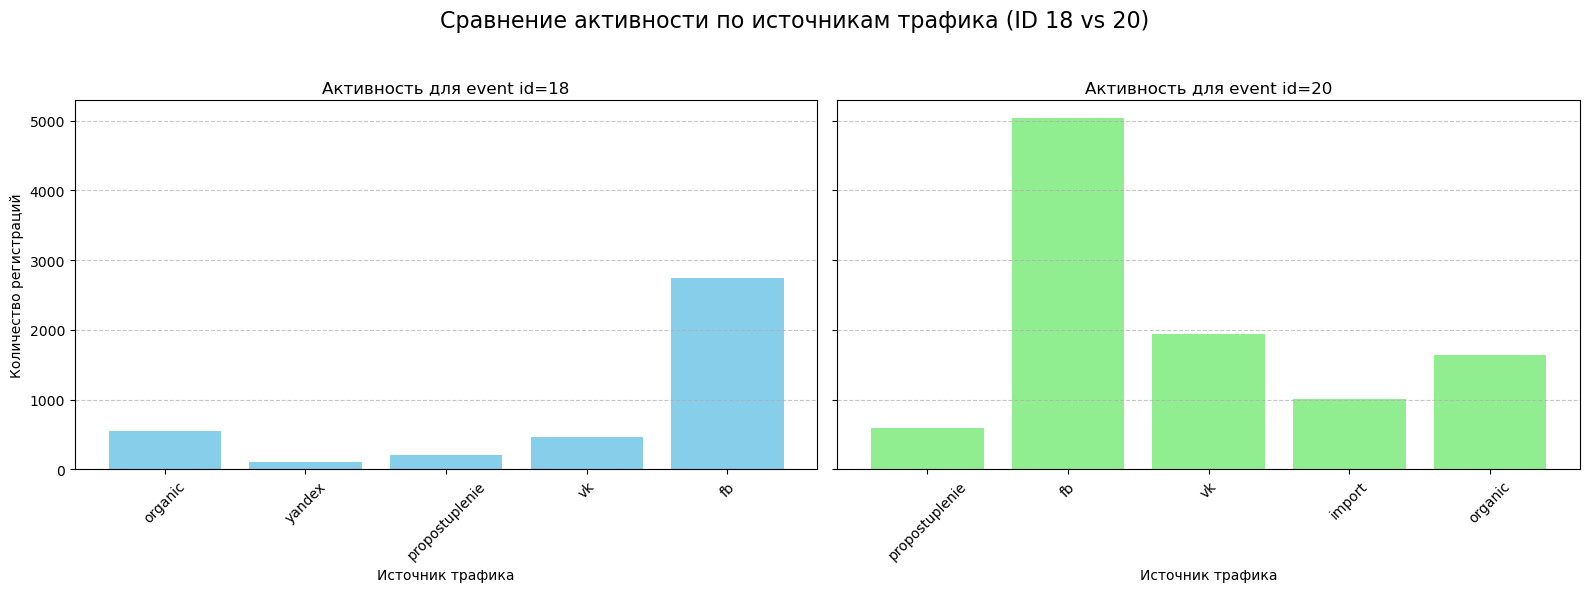

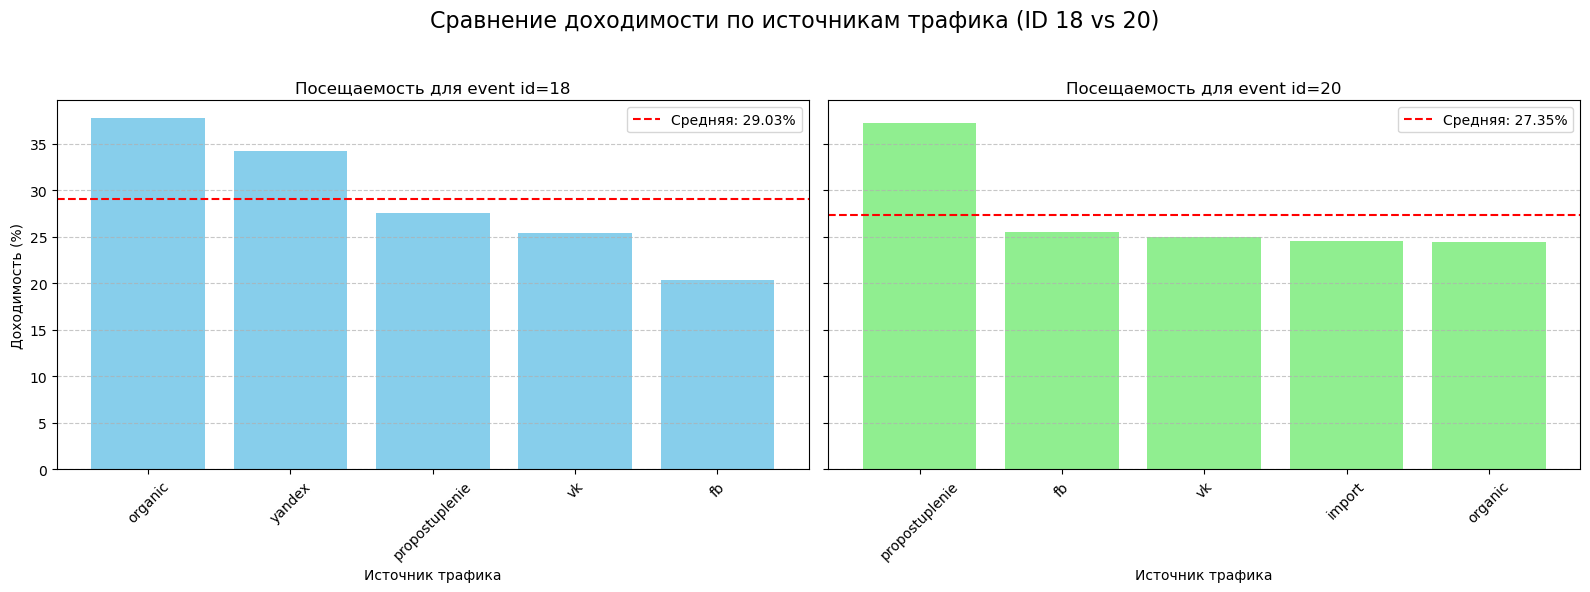

In [34]:
df1, df2 = compare_events(3, 17, metric='Registrations_count')
df1, df2 = compare_events(3, 17)

df1, df2 = compare_events(18, 20, metric='Registrations_count')
df1, df2 = compare_events(18, 20)

**Что можно заметить:**
* У менее массовых мероприятий (15, 18 и 20) доминирующий источник трафика - фейсбук (на него приходится более половины всех заявок) при этом худший по доходимости трафик также фейсбук.
* У более массовых (3, 17) доминирующий источник трафика - органический, который также показывает хорошую доходимость

Рекомендации:
* Итак, видимо какая-то внешняя деятельность привлекает людей наиболее эффективно по соотношению массовости и доходимости. Рекомендуется назначить основным источником трафика органический и работать над улучшениями здесь в первую очередь.
* Также можно рассмотреть перенос рекламного трафика с соц сетей (вк, фейсбук) на поисковые платформы (яндекс, гугл). В целом ранее писала почему это может быть выгодно.

### Эволюция каналов привлечения в хронологическом порядке (ID 3 -> 17 -> 18 -> 20)

- Ранний пик и доминирование органики (ID 3): На первом крупном мероприятии основной объем регистраций шел через **organic** (\~18 тыс.), который обеспечивал высокую доходимость (\~49%), в то время как *Facebook* уже тогда показывал худшую конверсию (\~25%).
- Перераспределение на поисковые системы (ID 17): На следующем этапе резко выросла роль **Yandex** и **Google**, которые перетянули на себя качественный трафик с рекордной доходимостью (58–64%), значительно превышающей средние показатели по проекту.
- Смещение в сторону платного трафика на спаде (ID 18 и 20): К моменту проведения поздних мероприятий структура трафика трансформировалась — на **ID 18** и **ID 20** объемы через *Facebook* и другие каналы выросли относительно общей базы, но общая доходимость по всем источникам просела до 27–29%, отражая общий спад интереса старшеклассников из-за экзаменов и неэффективность выбранных каналов привлечения.

### Гипотеза 4: Проверка гипотезы о влиянии каналов привлечения через тест Хи-квадрат


In [36]:
def test_channel_association(by, df, events, alpha=0.01, min_group_size=30):
    """
    Хи-квадрат тест независимости между категориальным признаком `by` и фактом посещения мероприятия.
    
    by: название столбца (или заранее созданный комбинированный столбец)
    df: полный датафрейм на уровне регистраций (new_reg)
    events: список EventID, которые включаем в тест
    min_group_size: минимальный размер группы, иначе исключаем (маленькие группы делают хи-квадрат ненадежным — ожидаемые частоты < 5)
    Возвращает chi2, p-value, dof, Cramér's V и саму таблицу сопряженности.
    """
    sub = df[df['EventID'].isin(events)].copy()
    sub['Was'] = sub['VisitID'].notna().astype(int)

    # оставляем только категории, присутствующие во ВСЕХ выбранных мероприятиях
    per_event = sub.groupby('EventID')[by].apply(set)
    common = set.intersection(*per_event)
    sub = sub[sub[by].isin(common)]

    # отсекаем слишком маленькие группы
    sizes = sub[by].value_counts()
    sub = sub[sub[by].isin(sizes[sizes >= min_group_size].index)]

    table = pd.crosstab(sub[by], sub['Was'])
    chi2, p, dof, expected = stats.chi2_contingency(table)

    # предупреждение, если ожидаемые частоты слишком малы (условие валидности теста)
    if (expected < 5).any():
        print("[WARNING] Есть ячейки с ожидаемой частотой < 5 — результат может быть ненадежным")

    n = table.values.sum()
    k = min(table.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k)) if k > 0 else np.nan

    print(f"Хи-квадрат: {by} vs посещение мероприятия")
    print(f"chi2 = {chi2:.2f}, dof = {dof}, p-value = {p:.4g}, Cramér's V = {cramers_v:.3f}")
    verdict = "связь статистически значима" if p < alpha else "связь статистически не значима"
    print(f"Вывод (alpha={alpha}): {verdict}")

    return chi2, p, dof, cramers_v, table

In [ ]:
events_to_test = [3, 17, 20, 18, 15]

In [38]:
# Гипотеза 4: источник трафика
_, p4, _, v4, table4 = test_channel_association('utm_source', new_reg, events_to_test)
display(table4)


Хи-квадрат: utm_source vs посещение мероприятия
chi2 = 3589.72, dof = 6, p-value = 0, Cramér's V = 0.206
Вывод (alpha=0.01): связь статистически значима


Was,0,1
utm_source,,
Mailigen,4677,2695
fb,17878,6144
google,787,735
organic,15405,14975
propostuplenie,6539,3896
vk,5474,2665
yandex,1347,1443


In [39]:
# Гипотеза 5: тип трафика
_, p5, _, v5, table5 = test_channel_association('utm_medium', new_reg, events_to_test)
display(table5)

Хи-квадрат: utm_medium vs посещение мероприятия
chi2 = 3235.41, dof = 5, p-value = 0, Cramér's V = 0.199
Вывод (alpha=0.01): связь статистически значима


Was,0,1
utm_medium,,
banner,6335,3773
cpa,17728,6045
cpc,5651,3490
email,4696,2699
organic,15747,15249
vuzy,90,54


In [40]:
# Гипотеза 6: комбинация источник + тип
new_reg['utm_combo'] = new_reg['utm_source'] + ' + ' + new_reg['utm_medium']
_, p6, _, v6, table6 = test_channel_association('utm_combo', new_reg, events_to_test)
display(table6)

Хи-квадрат: utm_combo vs посещение мероприятия
chi2 = 3744.32, dof = 9, p-value = 0, Cramér's V = 0.215
Вывод (alpha=0.01): связь статистически значима


Was,0,1
utm_combo,,
Mailigen + email,4590,2642
fb + cpa,17728,6045
fb + organic,93,80
google + cpc,783,724
organic + organic,15405,14975
propostuplenie + banner,6335,3771
propostuplenie + vuzy,90,54
vk + cpc,3538,1353
vk + organic,55,52


**Практический итог:**  
Каналы привлечения и их связки **статистически значимо влияют** на доходимость (вероятность визита на мероприятие).   

При этом коэффициент Cramér's V позволил оценить силу этой связи: 
- Полученные значения ($0.206$ для источников и $0.199$ для типов) находятся в диапазоне **умеренной (средней) силы связи**. 
- Таким образом, выбор канала привлечения действительно оказывает заметное и практически значимое влияние на доходимость, но при этом на решение пользователя прийти на мероприятие влияют и другие факторы (время, класс, дата и т.д.).

---
## Итоговые выводы и рекомендации по проекту

### 1. Эффективность каналов привлечения
* Поисковые системы и органика (Лидеры эффективности): *Yandex*, *Google* и *Organic* показывают наивысшую и статистически значимо лучшую доходимость на мероприятия (в диапазоне от 58% до 74%). Это доказывает, что поисковые алгоритмы качественнее учитывают намерения пользователей и геолокацию.
* Платная реклама в Facebook (Проблемная зона): *Facebook* приносит много регистраций за счет больших бюджетов, но демонстрирует стабильно самую низкую конверсию в реальный визит (около 20–25%), сильно уступая остальным каналам. Это подтверждено как графиками, так и строгим z-тестом пропорций.
* Статистическое подтверждение: Тест Хи-квадрат по источникам (`utm_source`) и типам трафика (`utm_medium`) подтвердил высокую значимость связи каналов с посещаемостью ($p < 0.001$), а умеренная сила связи по коэффициенту Крамера ($V \approx 0.20$) говорит о том, что канал — важный фактор успеха.

---

### 2. Временные паттерны
* Дни недели: Основной пик активности и максимальная доходимость приходятся на **пятницу и субботу**. В то же время *Facebook* часто расходует бюджет на будни (среда-четверг), когда конверсия проседает, упуская ключевые выходные дни.
* Время суток: Оптимальный интервал для показа рекламы и сбора регистраций — **с 9:00 до 21:00**, с абсолютным пиком активности и конверсии в утренние часы **10:00–11:00**. Ночное время (0:00–4:00) абсолютно неэффективно.

---

### 3. Эволюция аудитории и сезонность (Хронология: 15 -> 3 -> 17 -> 18 -> 20)
* Старт сезона (Осень): Первое мероприятие (ID 15) столкнулось с организационным сбоем, но уже на массовых событиях ID 3 и ID 17 зафиксирован пик интереса. В этот период доминируют 11-классники, которые наиболее активны в начале учебного года.
* Экзаменационный спад (Зима-Весна): На поздних мероприятиях (ID 18 и ID 20) общая активность и доходимость проседают (до 27–29%). Это предположительно связано с тем, что в феврале выпускники полностью погружаются в подготовку к ОГЭ и ЕГЭ, а локальный очный спрос в районе начинает исчерпываться.


---

### Рекомендации

1. **Перераспределение рекламного бюджета:** 
   * Снизить инвестиции в *Facebook* или полностью перенастроить его алгоритмы и аудиторные таргетинги, так как текущая воронка не окупает затраты по доходимости.
   * Увеличить упор на поисковые кампании в *Yandex* и развитие органического направления, которые привлекают самую мотивированную аудиторию.
2. **Корректировка по времени:** 
   * Фокусировать рекламные показы на пятницы и субботы, синхронизируя их с пиками посещаемости очных мероприятий.
   * Настраивать автоматический показ рекламы в дневные и вечерние часы с акцентом на утренний прайм-тайм (10:00–11:00).
3. **Сезонное зонирование аудитории:**
   * Осень: Максимально охватывать старшеклассников (10–11 классы), пока у них есть ресурс и высокий интерес к выбору будущего.
   * Зима / Ранняя весна (февраль–март): Смещать фокус кампаний на младшие параллели (**7–8 и 10 классы**), у которых еще нет давления экзаменов, но уже формируется потребность в профориентации. 
   * Младшие классы: Полностью исключить из рекламных таргетингов из-за критически малого объема аудитории, несмотря на их локально неплохую конверсию.